Imports

In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [139]:
df = pd.read_csv('../data/raw/bank-marketing.csv')
df.head()

,age,job,marital-status,education,default-credit,yearly-balance,housing-loan,personal-loan,last-contact-type,last-contact-day,last-contact-month,last-contact-duration-seconds,current-campaign-contacts,passed-days,previous-campaigns,outcome-previous-campaign,suscribed-term-deposited
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,?,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,?,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,?,0,unknown,no


There are a few things that got my attention. I noticed that some of the columns have ? marks so I think it needs to be cleaned.

Data Structure Summary

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   age                            4521 non-null   int64 
 1   job                            4521 non-null   object
 2   marital-status                 4521 non-null   object
 3   education                      4521 non-null   object
 4   default-credit                 4521 non-null   object
 5   yearly-balance                 4521 non-null   object
 6   housing-loan                   4521 non-null   object
 7   personal-loan                  4521 non-null   object
 8   last-contact-type              4521 non-null   object
 9   last-contact-day               4521 non-null   int64 
 10  last-contact-month             4521 non-null   object
 11  last-contact-duration-seconds  4521 non-null   int64 
 12  current-campaign-contacts      4521 non-null   int64 
 13  pas

In [141]:
df.shape

(4521, 17)

In [142]:
df.isnull().sum().sum()

np.int64(0)

In [143]:
df.duplicated().sum()

np.int64(0)

According to the dataset documentation, yearly-balance is a numeric variable but the column is imported as an object data type.

Summary Statistics

In [144]:
df.describe()

,age,last-contact-day,last-contact-duration-seconds,current-campaign-contacts,previous-campaigns
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,15.915284,263.961292,2.793630,0.542579
std,10.576211,8.247667,259.856633,3.109807,1.693562
min,19.000000,1.000000,4.000000,1.000000,0.000000
25%,33.000000,9.000000,104.000000,1.000000,0.000000
50%,39.000000,16.000000,185.000000,2.000000,0.000000
75%,49.000000,21.000000,329.000000,3.000000,0.000000
max,87.000000,31.000000,3025.000000,50.000000,25.000000


Summary statistics confirms that yearly-balance is not numerical as it is not listed above.

Before conducting EDA I wanted to address these quality data issues and see why is yearly-balance is treated as an object.

In [145]:
df.loc[pd.to_numeric(df['yearly-balance'], errors='coerce').isna()]

,age,job,marital-status,education,default-credit,yearly-balance,housing-loan,personal-loan,last-contact-type,last-contact-day,last-contact-month,last-contact-duration-seconds,current-campaign-contacts,passed-days,previous-campaigns,outcome-previous-campaign,suscribed-term-deposited
1770,38,blue-collar,single,secondary,no,?,yes,no,unknown,7,may,72,1,?,0,unknown,no
2162,40,admin.,single,secondary,no,?,no,no,cellular,7,jul,173,1,?,0,unknown,no
3494,50,blue-collar,married,primary,no,?,no,no,cellular,19,aug,195,2,?,0,unknown,no
3926,56,retired,married,primary,no,?,no,no,cellular,27,aug,89,23,?,0,unknown,no
4317,27,services,single,secondary,yes,?,no,no,cellular,22,jul,60,2,?,0,unknown,no


In [146]:
numeric_columns = [
    'age',
    'yearly-balance',
    'last-contact-day',
    'last-contact-duration-seconds',
    'current-campaign-contacts',
    'passed-days',
    'previous-campaigns'
]

for col in numeric_columns:
    invalid = pd.to_numeric(df[col], errors='coerce').isna().sum()
    print(f"{col}: {invalid}")

age: 0
yearly-balance: 5
last-contact-day: 0
last-contact-duration-seconds: 0
current-campaign-contacts: 0
passed-days: 3705
previous-campaigns: 0


In [147]:
df['yearly-balance'] = (df['yearly-balance'].replace('?', -1).astype(int))

In [148]:
df['passed-days'] = (df['passed-days'].replace('?', -1).astype(int))

Inspection of the school-provided dataset revealed that the passed-days variable used question marks (?) instead of the original value -1 to indicate that a client had not previously been contacted. Comparison with the original dataset confirmed that both representations referred to the same condition. Therefore, these values were converted back to -1 rather than treated as missing data. In contrast, five question-mark entries in the yearly-balance variable represented genuine missing values and were handled separately.

In [149]:
df.describe()

,age,yearly-balance,last-contact-day,last-contact-duration-seconds,current-campaign-contacts,passed-days,previous-campaigns
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1429.238222,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3005.769914,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,75.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,445.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [150]:
categorical_columns = [
    'job',
    'marital-status',
    'education',
    'last-contact-type',
    'last-contact-month',
    'outcome-previous-campaign'
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


job
['unemployed' 'services' 'management' 'blue-collar' 'self-employed'
 'technician' 'entrepreneur' 'admin.' 'student' 'housemaid' 'retired'
 'unknown']

marital-status
['married' 'single' 'divorced']

education
['primary' 'secondary' 'tertiary' 'unknown']

last-contact-type
['cellular' 'unknown' 'telephone']

last-contact-month
['oct' 'may' 'apr' 'jun' 'feb' 'aug' 'jan' 'jul' 'nov' 'sep' 'mar' 'dec']

outcome-previous-campaign
['unknown' 'failure' 'other' 'success']


In [151]:
binary_columns = [
    'default-credit',
    'housing-loan',
    'personal-loan',
    'suscribed-term-deposited'
]

for col in binary_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


default-credit
default-credit
no     4445
yes      76
Name: count, dtype: int64

housing-loan
housing-loan
yes    2559
no     1962
Name: count, dtype: int64

personal-loan
personal-loan
no     3830
yes     691
Name: count, dtype: int64

suscribed-term-deposited
suscribed-term-deposited
no     4000
yes     521
Name: count, dtype: int64


EDA

Target Variable Distribution

In [152]:
df['suscribed-term-deposited'].value_counts()

suscribed-term-deposited
no     4000
yes     521
Name: count, dtype: int64

In [153]:
df['suscribed-term-deposited'].value_counts(normalize=True) * 100

suscribed-term-deposited
no     88.476001
yes    11.523999
Name: proportion, dtype: float64

In [154]:
subscribed = df['suscribed-term-deposited'].value_counts().sort_index()
subscribed.index = ['Not Subscribed', 'Subscribed']

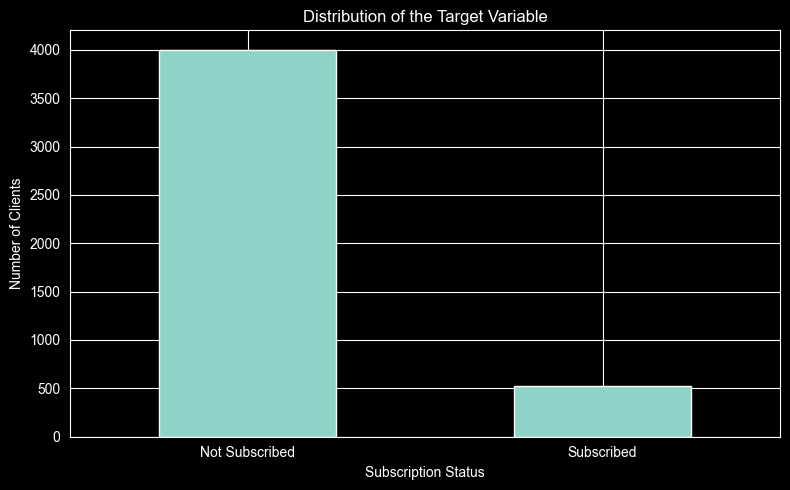

<Figure size 800x500 with 0 Axes>

In [155]:
plt.figure(figsize=(8, 5))
subscribed.plot(kind="bar")

plt.title("Distribution of the Target Variable")
plt.xlabel("Subscription Status")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig('../images/Figure_A1_Subscription_Distribution.png')
plt.figure(figsize=(8, 5))
plt.show()

Numerical Value Distribution

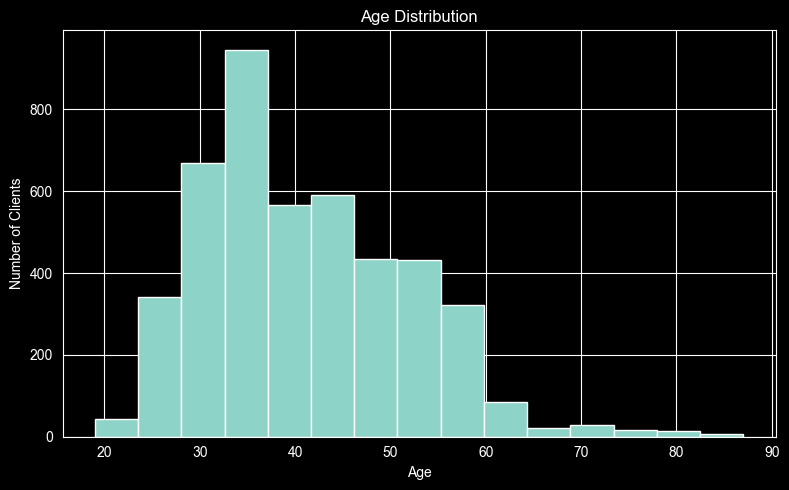

In [156]:
plt.figure(figsize=(8, 5))

plt.hist(df['age'], bins=15)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Clients')

plt.tight_layout()
plt.savefig('../images/Figure_A2_Age_Distribution.png')
plt.show()

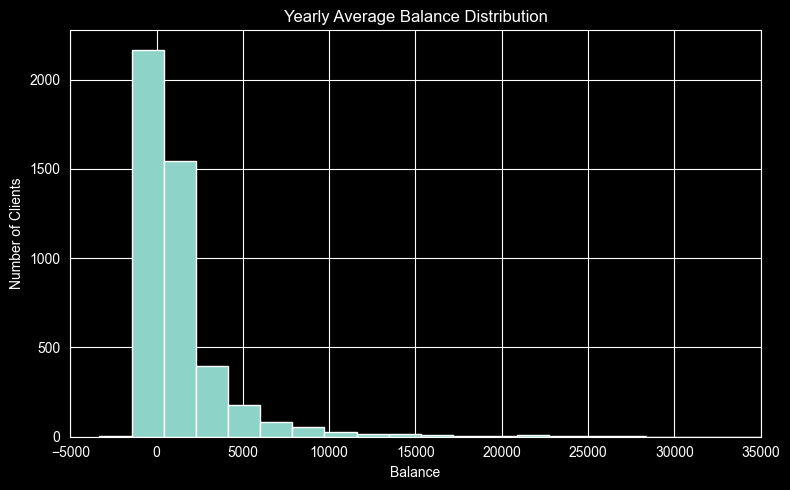

In [157]:
plt.figure(figsize=(8, 5))

plt.hist(df['yearly-balance'], bins=40)

plt.xlim(-5000, 35000)

plt.title('Yearly Average Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Number of Clients')

plt.tight_layout()
#plt.savefig('../images/Figure_A3_Balance_Distribution.png')
plt.show()

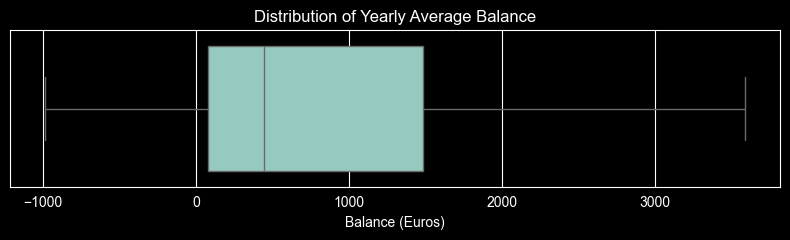

In [158]:
plt.figure(figsize=(8,2.5))

sns.boxplot(x=df['yearly-balance'], showfliers=False)

plt.title('Distribution of Yearly Average Balance')
plt.xlabel('Balance (Euros)')

plt.tight_layout()
plt.show()

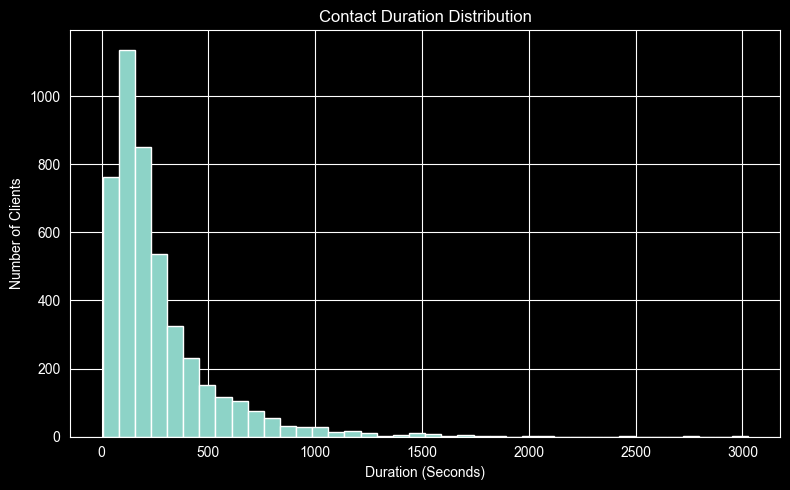

In [159]:
plt.figure(figsize=(8, 5))

plt.hist(df['last-contact-duration-seconds'], bins=40)

#plt.xlim(-5000, 35000)

plt.title('Contact Duration Distribution')
plt.xlabel('Duration (Seconds)')
plt.ylabel('Number of Clients')

plt.tight_layout()
#plt.savefig('../images/Figure_A3_Balance_Distribution.png')
plt.show()

Categorical Variable Distribution

In [160]:
jobs = df['job'].value_counts().sort_index()
jobs

job
admin.           478
blue-collar      946
entrepreneur     168
housemaid        112
management       969
retired          230
self-employed    183
services         417
student           84
technician       768
unemployed       128
unknown           38
Name: count, dtype: int64

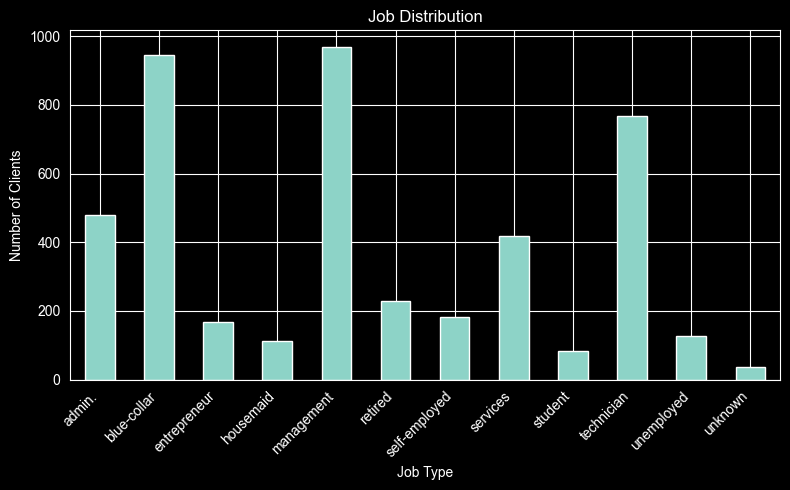

In [161]:
plt.figure(figsize=(8, 5))
jobs.plot(kind="bar")

plt.xticks(rotation=45, ha='right')

plt.title('Job Distribution')
plt.xlabel('Job Type')
plt.ylabel('Number of Clients')

plt.tight_layout()
#plt.savefig('../images/Figure_A3_Balance_Distribution.png')
plt.show()

In [162]:
marital = df['marital-status'].value_counts().sort_index()
marital

marital-status
divorced     528
married     2797
single      1196
Name: count, dtype: int64

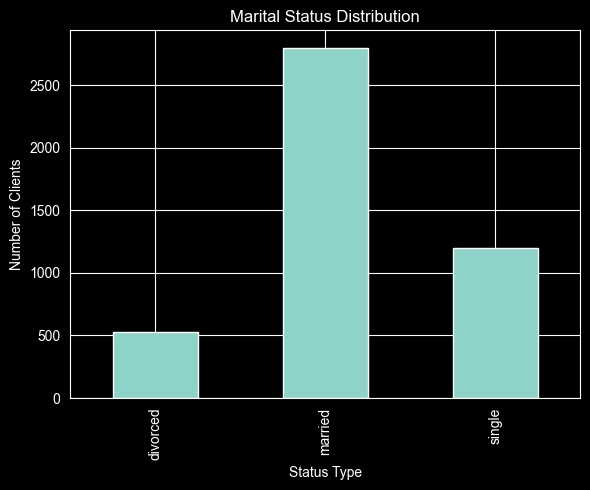

In [163]:
plt.figure(figsize=(6, 5))
marital.plot(kind="bar")

plt.title('Marital Status Distribution')
plt.xlabel('Status Type')
plt.ylabel('Number of Clients')

plt.tight_layout()
#plt.savefig('../images/Figure_A3_Balance_Distribution.png')
plt.show()

In [164]:
education = df['education'].value_counts().sort_index()
education

education
primary       678
secondary    2306
tertiary     1350
unknown       187
Name: count, dtype: int64

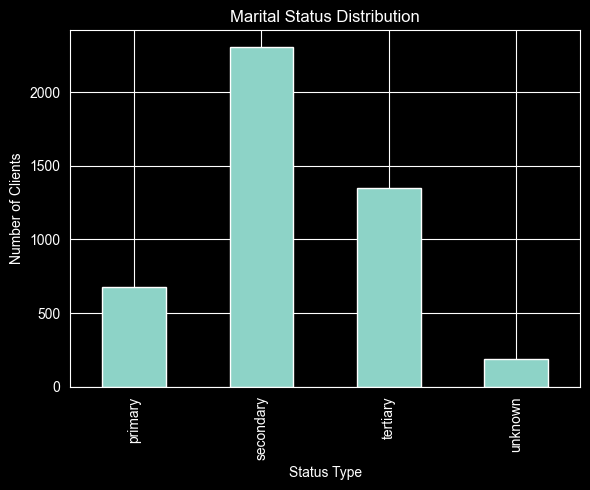

In [165]:
plt.figure(figsize=(6, 5))
education.plot(kind="bar")

plt.title('Marital Status Distribution')
plt.xlabel('Status Type')
plt.ylabel('Number of Clients')

plt.tight_layout()
#plt.savefig('../images/Figure_A3_Balance_Distribution.png')
plt.show()

Text(0, 0.5, 'Contact Duration (Seconds)')

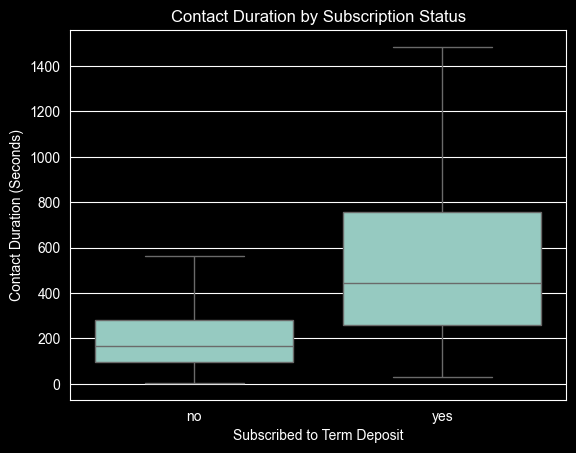

In [170]:
sns.boxplot(
    x='suscribed-term-deposited',
    y='last-contact-duration-seconds',
    data=df,
    showfliers=False
)

plt.title('Contact Duration by Subscription Status')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Contact Duration (Seconds)')

Text(0, 0.5, 'Yearly Average Balance (Euros)')

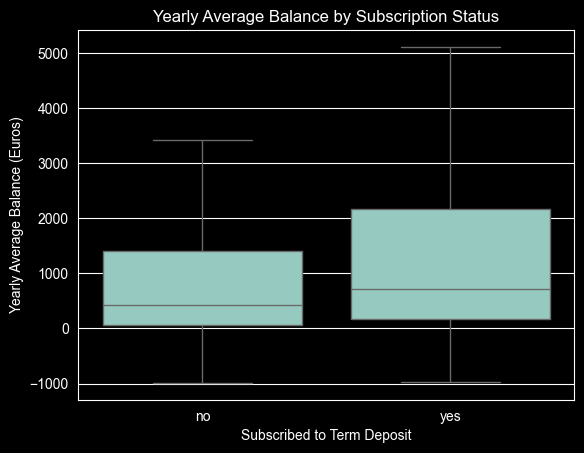

In [171]:
sns.boxplot(
    x='suscribed-term-deposited',
    y='yearly-balance',
    data=df,
    showfliers=False
)

plt.title('Yearly Average Balance by Subscription Status')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Yearly Average Balance (Euros)')